In [1]:
from config_file import *
sys.path.append('/export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/problems')
from train import *

In [2]:
print_problem()

# Load and preprocess the data
# Load the label data
labels = pd.read_csv(DATA_DIR + '/fusion_labels.csv')
# Load tabular data and remove unnecessary columns for model input
tab = pd.read_csv(DATA_DIR + '/tab_data.csv')
tab.drop(columns=['A', 'B', 'C', 'id', 'Feature14', 'Feature13', 'Feature12', 'Feature11', 'Feature10'], inplace=True)
# Combine the tabular data and labels into a single DataFrame for training
data = pd.concat([tab, labels], axis=1)
# Apply a transformation to create a new target column 'y'
data['y'] = get_y(data)

seed = set_seed(SEED) # Set the random seed for reproducibility
nas = {"img_fts": IMG_FTS, "tab_fts": TAB_FTS}
print(nas)

!!!!!!!!!!!!!!!! Durability Problem: 40 * circle(yes/no) - 20 * square(yes/no) + 20 * (t0 + t1) + 20; TRAINING =  seq ; WTS =  single ; TEMPFREEZE =  False ; INPUT =  fusion
1.0  < Y <  100.0
{'img_fts': 3, 'tab_fts': 1}


In [3]:
# Split data into training and testing folds
for i, (train_idx, test_idx) in enumerate(split_data(data, seed)):
    if i == BEST_FOLD:
        train_loader, val_loader, test_loader = get_dataloaders(data, train_idx, test_idx, seed)
        model, loss_fn = initialise_model(i, nas, True) # initialise the model according to prediction type and training procedure
        wts_dir = save_dir = REPO_DIR + MODEL_DIR[1:] + INPUT + '_' + TRAINING + '_' + WTS + '_Freeze_' + str(TEMP_FREEZE) + '.pth'
        model.load_state_dict(torch.load(wts_dir), strict=False)
        loss, auroc, bacc = eval_model(model, test_loader, loss_fn)  # Evaluate the model
        break

In [4]:
# Check Evaluation Metrics
print("*** BEST FOLD METRICS ***")
print("* Loss = ", loss)
print("* AUROC = ", auroc)
print("* BAcc = ", bacc)

*** BEST FOLD METRICS ***
* Loss =  200.38702189834788
* AUROC =  0.5
* BAcc =  0.5


# Generate Image Explanations with Grad-CAM

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2  # If not installed, install using 'pip install opencv-python'

iterator = iter(test_loader)

Y = [[26.]]
Y_pred = tensor([[30.6765]])
IMG_PRED -> tensor([[0.4593, 0.4598, 0.5731]])
TAB_PRED -> tensor([[0.1072]])
T1 > T2: 0.2828069625764096 > 0.1201965612131689


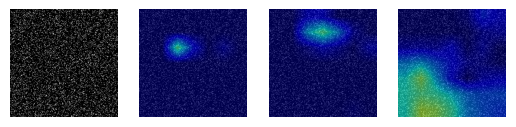

Y = [[20.]]
Y_pred = tensor([[36.5138]])
IMG_PRED -> tensor([[0.4764, 0.4668, 0.5107]])
TAB_PRED -> tensor([[0.0815]])
T1 > T2: 0.6674103799636817 > 0.1317978624043921


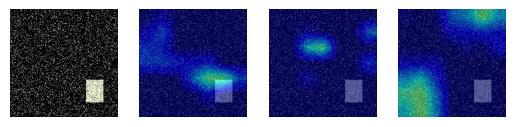

Y = [[13.]]
Y_pred = tensor([[17.1142]])
IMG_PRED -> tensor([[0.4112, 0.3698, 0.5917]])
TAB_PRED -> tensor([[0.1067]])
T1 > T2: 0.4205394666800984 > 0.5573687913239169


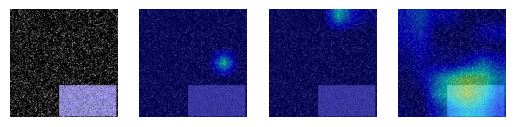

Y = [[39.]]
Y_pred = tensor([[32.1880]])
IMG_PRED -> tensor([[0.5011, 0.4815, 0.5467]])
TAB_PRED -> tensor([[0.1489]])
T1 > T2: 0.7885455123065187 > 0.0568480764332403


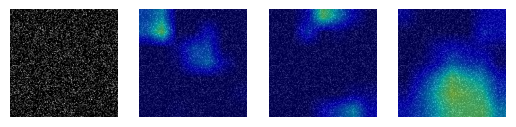

Y = [[79.]]
Y_pred = tensor([[76.8505]])
IMG_PRED -> tensor([[0.4333, 0.4447, 0.3739]])
TAB_PRED -> tensor([[0.0124]])
T1 > T2: 0.990345001560894 > 0.4090540953730616


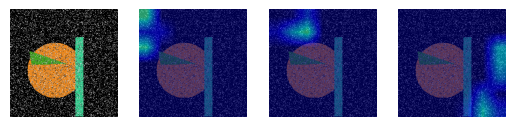

Y = [[60.]]
Y_pred = tensor([[58.9303]])
IMG_PRED -> tensor([[0.4672, 0.4625, 0.4139]])
TAB_PRED -> tensor([[0.0727]])
T1 > T2: 0.554687808661419 > 0.2870515199196297


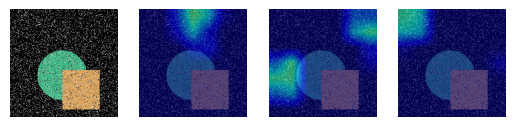

Y = [[38.]]
Y_pred = tensor([[32.2441]])
IMG_PRED -> tensor([[0.4933, 0.4454, 0.4338]])
TAB_PRED -> tensor([[0.1072]])
T1 > T2: 0.5305372145627818 > 0.922111461767193


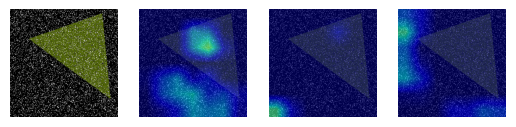

Y = [[73.]]
Y_pred = tensor([[64.4566]])
IMG_PRED -> tensor([[0.3790, 0.5542, 0.4272]])
TAB_PRED -> tensor([[0.1459]])
T1 > T2: 0.647196653894036 > 0.6003922370976396


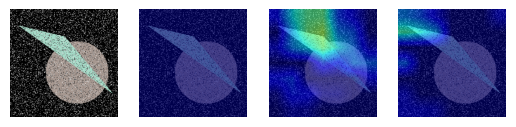

Y = [[59.]]
Y_pred = tensor([[64.8177]])
IMG_PRED -> tensor([[0.4466, 0.4588, 0.4706]])
TAB_PRED -> tensor([[0.0928]])
T1 > T2: 0.5910269008704913 > 0.6591764718500283


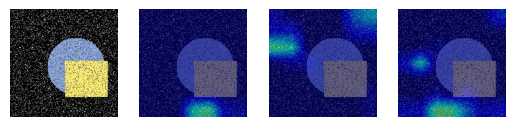

Y = [[46.]]
Y_pred = tensor([[49.1214]])
IMG_PRED -> tensor([[0.4154, 0.4699, 0.4068]])
TAB_PRED -> tensor([[0.2310]])
T1 > T2: 0.2419017042014848 > 0.4322814811812986


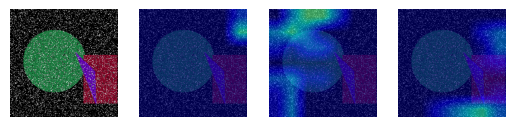

In [6]:
for i in range(10):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # Register hooks in the layer of interest
    target_layer = model.img_block.resnet.layer4[-1]
    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = model.img_block(*model_input).size(1)

    y_pred = model(*model_input).detach().cpu()
    a_pred = model.img_block(*model_input).detach().cpu()
    b_pred = model.tab_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG_PRED -> {a_pred}")
    print(f"TAB_PRED -> {b_pred}")
    print(f"T1 > T2: {t1} > {t2}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for cls in range(num_classes):
        #print(f"Generating Grad-CAM for feature {cls + 1} of {num_classes}...")

        # Register hooks
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = model.img_block(*model_input)

        # Select the output for the specific class (image feature)
        class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        class_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = class_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, cls+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


# Generate files for GP-GOMEA
* we need the tabular features and the engineered tabular features to feed to GPG
* we also safe files with the engineered features (img and tab) and the true labels

In [7]:
import pandas as pd
import numpy as np

if not os.path.exists(GP_DIR):
        os.makedirs(GP_DIR)

dataloaders = [('train', train_loader), ('test', test_loader)]

with torch.no_grad():
    for split, loader in dataloaders:
        # Initialize tab_fts, I, T, Y arrays
        tab_fts, all_I, all_T, all_Y = [], [], [], []
        
        # Iterate through the dataloader and extract the features
        for i, (img, tab, _, _, y) in enumerate(loader):
            img, tab, y = img.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float), y.to(DEVICE, dtype=torch.float)
            
            # Get the outputs from model blocks
            I = model.img_block(img, tab)
            T = model.tab_block(img, tab)
            
            # if multiclass
            # Y = np.argmax(y.cpu().numpy(), axis=1)
            
            
            # Convert tensors to numpy and handle dimensions carefully
            tab_fts.append(tab.cpu().numpy())           # Keep tab_fts as is
            all_I.append(I.cpu().numpy())               # Append I features (variable column sizes)
            all_T.append(T.cpu().numpy())               # Append T features
            all_Y.append(y.cpu().numpy())               # Append labels

        # Convert lists to NumPy arrays and ensure consistent shape by concatenating along axis 0
        tab_fts_np = np.concatenate(tab_fts, axis=0)     # Stack rows for tab_fts
        all_I_np = np.concatenate(all_I, axis=0)         # Stack rows for all_I
        all_T_np = np.concatenate(all_T, axis=0)         # Stack rows for all_T
        all_Y_np = np.concatenate(all_Y, axis=0)         # Stack rows for all_Y

        # Ensure all_Y has a consistent shape, even if it has only one column
        if all_Y_np.ndim == 1:
            all_Y_np = all_Y_np[:, np.newaxis]           # Make sure all_Y is 2D (n, 1)

        # Create DataFrame for the first file (all_I, all_T, all_Y)
        df_1 = pd.DataFrame(
            data=np.hstack([all_I_np, all_T_np, all_Y_np]),  # Horizontally concatenate arrays
            columns=[f'I{i+1}' for i in range(all_I_np.shape[1])] +  # Name all_I columns
                    [f'T{i+1}' for i in range(all_T_np.shape[1])] +  # Name all_T columns
                    ['Y']  # Name the target column (all_Y)
        )
        
        # Create DataFrame for the second file (tab_fts, all_T)
        df_2 = pd.DataFrame(
            data=np.hstack([tab_fts_np, all_T_np]),  # Horizontally concatenate tab_fts and all_T
            columns=[f'tab_fts_col_{i+1}' for i in range(tab_fts_np.shape[1])] +  # Name tab_fts columns
                    [f'T{i+1}' for i in range(all_T_np.shape[1])]  # Name all_T columns
        )

        # Save both DataFrames as CSV files
        file_1 = GP_DIR + f'{split}_dl_I_T_Y.csv'
        df_1.to_csv(file_1, index=False)
        print(f"Saved {file_1}!")
        
        file_2 = GP_DIR + f'{split}_tab_T.csv'
        df_2.to_csv(file_2, index=False)
        print(f"Saved {file_2}!")

print(nas)

Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/train_dl_I_T_Y.csv!
Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/train_tab_T.csv!
Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/test_dl_I_T_Y.csv!
Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/test_tab_T.csv!
{'img_fts': 3, 'tab_fts': 1}


In [ ]:
from config_file import *
print_problem()

In [ ]:
print(IMG_FTS)
print(TAB_FTS)

In [8]:
# replace DL T with GP T
def gp_T1(tab_fts):
    # copy expression here
    # ((1.556495 - x_0) / (-3.195519)**2)
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        x_3 = tab_fts[i,3]
        x_4 = tab_fts[i,4]
        x_6 = tab_fts[i,6]
        x_9 = tab_fts[i,9]
        
        #if (x_0 > x_6): y.append(1/(1.542552))
        #else: y.append(1.528704 + -0.853883)
        
        r = ((1.556495 - x_0) / (-3.195519)**2)
        if r > 1: y.append(1)
        elif r < 0: y.append(0)
        else: y.append(r)
        
    return y

In [10]:
# replace DL T with GP T
def gp_T2(tab_fts):
    # copy expression here
    # ((2.715843 - x_0) / (4.192594 + x_1))
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        x_3 = tab_fts[i,3]
        x_4 = tab_fts[i,4]
        
        #if (0.500307 < x_0): y.append(0.503676)
        #else: y.append((-0.714243)**2)
        
        #y.append((0.073608 * x_0) - (-0.760951)**3)
        
        r = 1/((1.924500 + x_0))
        if r > 1: y.append(1)
        elif r < 0: y.append(0)
        else: y.append(r)
        
    return y

In [5]:
# replace DL T with GP T
def gp_T3(tab_fts):
    # copy expression here
    # ([-](-1.203188) / (x_0 - -2.034068))
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        x_3 = tab_fts[i,3]
        x_4 = tab_fts[i,4]
        
        r = ((1.203188) / (x_0 + 2.034068))
        if r > 1: y.append(1)
        elif r < 0: y.append(0)
        else: y.append(r)
    return y

the part below was wrong: using engineering fts from both modalities to create new tab fts

In [9]:
# load DL data
train_data = pd.read_csv(GP_DIR + f'train_dl_I_T_Y.csv')
test_data = pd.read_csv(GP_DIR + f'test_dl_I_T_Y.csv')
train_fts = pd.read_csv(GP_DIR + f'train_tab_T.csv')
test_fts = pd.read_csv(GP_DIR + f'test_tab_T.csv')

# calculate new T ft(s)
train_T1 = gp_T1(train_fts)
test_T1 = gp_T1(test_fts)
#train_T2 = gp_T2(train_fts)
#test_T2 = gp_T2(test_fts)
#train_T3 = gp_T3(train_fts)
#test_T3 = gp_T3(test_fts)

# replace T in fusion file
train_data['T1'] = train_T1
test_data['T1'] = test_T1
#train_data['T2'] = train_T2
#test_data['T2'] = test_T2
#train_data['T3'] = train_T3
#test_data['T3'] = test_T3

# save new files
train_file = GP_DIR + f'train_I_T_Y.csv'
train_data.to_csv(train_file, index=False)
print(f"Saved {train_file}!")

test_file = GP_DIR + f'test_I_T_Y.csv'
test_data.to_csv(test_file, index=False)
print(f"Saved {test_file}!")

Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/train_I_T_Y.csv!
Saved /export/scratch1/home/malafaia/MultiFIX_ProofOfConcept/gp_files/Regression2/seq_single_False/test_I_T_Y.csv!


In [ ]:
from config_file import *
print_problem()

In [ ]:
print(IMG_FTS)
print(TAB_FTS)

In [3]:
# GP symbolic expression for prediction
def gp_Y(tab_fts):
    # copy expression here
    # ((x_1 + x_2) * (4.069701)**3)
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        #x_3 = tab_fts[i,3]
        #x_4 = tab_fts[i,4]
        #x_5 = tab_fts[i,5]
        
        y.append(((x_1 + x_2) * (4.069701)**3))
        
    return y

In [ ]:
# Compute Final Performance
dl_data = pd.read_csv(GP_DIR + f'test_dl_I_T_Y.csv')
gt = np.asarray(dl_data['Y']).reshape(200,)
gp_data = pd.read_csv(GP_DIR + f'test_I_T_Y.csv')
gp = np.asarray(gp_Y(gp_data)).reshape(200,)


bacc = balanced_accuracy_score(gt, gp)
print("Final BAcc = ", bacc)